---
# **Análisis y Predicción de la Viralidad del Contenido de TikTok mediante Machine Learning** 

### Trabajo de Fin de Máster - Universidad de Madrid (UCM)

**Autora:** Rocío Pérez Holgado.

---
## **Estructura del Proyecto**

* **Cuaderno 1:** `01_Carga_y_Exploracion_Incial.ipynb`.
* **Cuaderno 2:** `02_Limpieza_EDA_Feature_Engineering.ipynb` **(Este cuaderno)**.

---
## **Índice - Cuaderno 2:**
1. **Importación de Librerías**.
2. **Carga de los Datasets**.
3. **Limpieza y Preprocesamiento de los Datos**.
    * 3.1. Columnas Irrelevantes.
    * 3.2. Cambiar Tipología de Variables (dtypes).
    * 3.3. Datos Faltantes o Nulos.
    * 3.4. Valores atípicos (Outliers).
4. **Definición de la Variable Objetivo**.
5. **Unificación de los Datasets**.
6. **EDA del dataset unificado.**.
    * 6.1. Estructura General del Dataset.
    * 6.2. Distribución de la Variable Objetivo.
    * 6.3. Variables Categóricas y Viralidad.
    * 6.4. Variables Numéricas y Viralidad.
    * 6.5. Correlación entre Variables Numéricas y Viralidad.
    * 6.6. Conclusiones del EDA.
8. **Ingeniería de Características (Feature Engineering)**.
    * 7.1. Tratamiento de Valores Nulos Restantes.
    * 7.2. Características Temporales de Publicación.
    * 7.3. Características Derivadas del Contenido.
    * 7.4. Transformaciones Logarítmicas y Métricas del Creador.
    * 7.5. Eliminación de Variables no Utilizables Directamente.
    * 7.6. Comprobaciones de las Nuevas Características.
10. **Comprobaciones Finales del Dataset**.
    * 8.1. Dimensiones y Estructura Final.
    * 8.2. Valores Nulos y Valores Infinitos.
    * 8.3. Duplicados e Identificadores.
    * 8.4. Variables Constantes y Fuga de Información.
    * 8.5. Variable Objetivo y Tipos de Datos.
12. **Exportación del Dataset Preparado**.

---
## **1. Importación de Librerías**

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## **2. Carga de los Datasets**

In [2]:
videos_df = pd.read_parquet("../datos/videos.parquet")
engagement_df = pd.read_parquet("../datos/engagement_daily.parquet")
creator_df = pd.read_parquet("../datos/creator_daily.parquet")

---
## **3. Limpieza y Preprocesamiento de los Datos**

#### **3.1. Columnas Irrelevantes**
---

Las columnas irrelevantes son aquellas que no aportan información útil para el análisis o predicción y, por tanto, se pueden eliminar del conjunto de datos para simplificar y reducir el dataset.

Las columnas irrelevantes pueden ser: 
* **Columnas que contienen información equivalente**, es decir, variables, que representan el mismo concepto mediante diferentes formatos.
* **Columnas con información redundante o duplicada**.
* **Columnas identificativas**, solo se usan para identificar registros y no contiene información predictiva.
* **Columnas que no aportan información relevante para el objetivo del estudio**, debido a que su contenido no tiene utilidad para el análisis.
* **Variables que pueden provocar fuga de información (data leakage)**, cuando contienen información que únicamente seria disponible despues del momento en el que se realiza la predicción.

In [3]:
videos_df = videos_df.drop(columns=["is_ads"], errors="ignore")

* Elimninado porque como vimos anteriormente era un valor constante.

Comprobar que se ha eliminado de forma correcta:

In [4]:
print("Columnas de videos:", videos_df.columns.tolist())

Columnas de videos: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'desc', 'sticker_text', 'hashtags', 'created_by_ai', 'music_selected_from', 'music_album', 'music_author', 'music_owner_id', 'music_id', 'music_title', 'transcript', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'gpt_summary', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear']


In [5]:
creator_df = creator_df.drop(columns=["enterprise_verified"], errors="ignore")

* Elimninado porque todos sus registros eran nulo. 

Comprobar que se ha eliminado de formna correcta:

In [6]:
print("\nColumnas de creator:", creator_df.columns.tolist())


Columnas de creator: ['author_id', 'date', 'follower_count', 'following_count', 'total_favorited', 'video_count']


**Nota importante:** Las variables identificadoras (claves primarias) de las tablas no han sido eliminadas porque son necesarias para validar y unificar las tablas más adelante.

#### **3.2. Cambiar Tipología de Variables (dtypes)**
---

##### **Variable fecha/hora**

Variables fecha/hora que habia que cambiar a `datetime`:
* Tabla `videos`: `create_time` y `create_date`.
* Tabla `engagement`: `date`.
* Tabla `creator`: `date`.
* Todas ellas almacenadas como `str`.

In [7]:
videos_df["create_time"] = pd.to_datetime(
    videos_df["create_time"],
    errors="coerce"
)

In [8]:
videos_df["create_date"] = pd.to_datetime(
    videos_df["create_date"],
    errors="coerce"
)

Una vez pasadas a `datetime` (más seguro para la comparación), podemos comprobar si las dos variables son iguales para todos los registros:
* Si devuelve true, coinciden en todos los registros y por tanto, una de ellas se puede eliminar.

In [9]:
(videos_df["create_time"].dt.date == videos_df["create_date"].dt.date).all()

np.True_

* Elegimos eliminar `create_date` debido a que solo almacena la fecha mientras que `create_time` es un `TIMESTAMP`. Esto quiere decir que almacena una marca tiempo completa (hh:mm:sss).
* Por tanto, si necesitamos trabajar con la fecha podemos extraerla de `create_time`, al igual que cualquier tipo de dato relacionado con la marca de tiempo.
* Si eliminasemos, `create_time` estaríamos perdiendo información y no tendriamos forma de recuperarla.

In [10]:
videos_df = videos_df.drop(columns=["create_date"], errors="ignore")

Volvemos a convertir las variables en tipo `date`:

In [11]:
engagement_df["date"] = pd.to_datetime(
    engagement_df["date"],
    errors="coerce"
)

In [12]:
creator_df["date"] = pd.to_datetime(
    creator_df["date"],
    errors="coerce"
)

#### **3.3. Datos Faltantes o Nulos**
---

Existen varias formas de manejar los datos faltantes:
  1. **Eliminar filas con registros faltantes:**
        * Descartar las filas quer contienen datos nulos.
        * Ventajas:
            * Útil en conjunto de datos grandes.
        * Desventaja:
            * En conjuntos de datos pequeños, puede afectar a la calidad del modelo al reducir la cantidad de datos para el entrenamiento. 
  2. **Eliminar la columna:**
        * Eliminar toda la columna si una proporción significativa de sus valores es nula.
        * Ventajas:
            * Sencillo y fácil de aplicar.
        * Desventaja:
            * Eliminar una columna puede deteriorar la calidad del modelo si dicha columna contiene información importante. Antes de hacer esto, debemos evaluar la importancia de la columna.
  3. **Imputación simple:**
        * Para las variables categoricas:
            * Rellenar los valores faltantes con la categoría que aparece con mayor frecuencia (moda).
        * Para las variables cuantitativas:
            * Sustituir valores perdidos por la media o la continua.
            * Se usará la mediana si la distribución es asimétrica.
            * Se usará la media si la distribución es simétrica.
        * Ventaja:
            * No elimina filas ni columnas.
        * Desventaja:
            * Puede introducir sesgos que afecten a la calidad del modelo.
  5. **Imputación por modelos:**
     * Aplicar algoritmos de machine learning para predecir y reemplazar los valores faltantes en función de otros datos disponibles.
        * Ventaja:
            * Permite conservar la integridad del conjunto de daots y, si el modelo está bien diseño, puede reducir el sesgo.
        * Desventaja:
            * Requiere una cantidad suficiente de datos para entrenar el modelo. Además la calidad de la imputación depende de la precisión del modelo que será entrenado con esos datos. Por tanto, si no tenemos suficientes datos para entrenar bien al modelo, no haremos una buena imputación.
            * Proceso complejo.
 6. **Crear una nueva categoría para los datos faltantes:**
    * Si la presencia de valores pérdidos es muy grande, deberíamos crear una nueva categoría llamada "Desconocido" o "No disponible" para ellos.

In [13]:
columnas_recuento_videos = [
    "word_count",
    "emoji_count",
    "question_count",
    "hashtag_count"
]

videos_df[columnas_recuento_videos] = (
    videos_df[columnas_recuento_videos]
    .fillna(0)
    .astype("int64")
)

videos_df["speaking_rate"] = videos_df["speaking_rate"].fillna(0)

* Variables numéricas derivadas de texto o audio:
* Un valor nulo representa ausencia de texto, emojis, preguntas, hashtags o voz. Por ello se imputa con 0.

In [14]:
# hashtags contiene listas de objetos y no puede utilizarse directamente
# como variable predictora.

# Se conserva hashtag_count, que ya recoge el número de hashtags
# de cada vídeo.

videos_df = videos_df.drop(columns="hashtags")

In [15]:
columnas_emociones = [
    "anger",
    "joy",
    "surprise",
    "sadness",
    "disgust",
    "fear"
]

filas_antes = len(videos_df)

videos_df = videos_df.dropna(subset=columnas_emociones)

* Se eliminan los registros con valores nulos en alguna emoción.
* Debido a que como hemos visto antes solo representan aproximadamente el 0,47 % del dataset.

In [16]:
columnas_texto = [
    "desc",
    "sticker_text",
    "music_album",
    "music_author",
    "music_title",
    "transcript",
    "gpt_summary"
]

for columna in columnas_texto:
    videos_df[columna] = videos_df[columna].fillna("Sin información")

* Sustituido los valores nulos por la etiqueta `Sin informacion`.

In [17]:
videos_df["desc_language"] = videos_df["desc_language"].fillna("Desconocido")

videos_df["topic"] = videos_df["topic"].fillna("Desconocido")

videos_df["music_selected_from"] = (
    videos_df["music_selected_from"]
    .fillna("Desconocido")
)

videos_df["music_id"] = videos_df["music_id"].fillna("SIN_IDENTIFICAR")

videos_df["music_owner_id"] = (
    videos_df["music_owner_id"]
    .fillna("SIN_IDENTIFICAR")
)

* Variables categóricas e identificadores musicales sustituyen nulos por etiquetas. 

In [18]:
# Variables numéricas de creator_df:
# Representan el 0.07% de los registros totales, se pueden imputar directamente
columnas_recuento_creator = [
    "follower_count",
    "following_count",
    "video_count"
]

creator_df = creator_df.dropna(subset=columnas_recuento_creator)

In [19]:
# created_by_ai:
# Primero se rellena su único valor nulo con 0.
# Después se convierte de float64 a int64.

videos_df["created_by_ai"] = videos_df["created_by_ai"].fillna(0)

videos_df["created_by_ai"] = videos_df["created_by_ai"].astype("int64")

In [20]:
# Comprobación final de valores nulos.

print("Valores nulos en videos:")
display(videos_df.isnull().sum().sort_values(ascending=False))

print("Valores nulos en engagement:")
display(engagement_df.isnull().sum().sort_values(ascending=False))

print("Valores nulos en creator:")
display(creator_df.isnull().sum().sort_values(ascending=False))

Valores nulos en videos:


video_id               0
author_id              0
disgust                0
sadness                0
surprise               0
joy                    0
anger                  0
topic                  0
gpt_summary            0
speaking_rate          0
hashtag_count          0
question_count         0
emoji_count            0
word_count             0
transcript             0
music_title            0
music_id               0
music_owner_id         0
music_author           0
music_album            0
music_selected_from    0
created_by_ai          0
sticker_text           0
desc                   0
is_english             0
desc_language          0
ratio                  0
duration               0
create_time            0
fear                   0
dtype: int64

Valores nulos en engagement:


video_id                0
date                    0
days_since_post         0
play_count              0
like_count              0
comment_count           0
share_count             0
collect_count           0
download_count          0
whatsapp_share_count    0
dtype: int64

Valores nulos en creator:


author_id          0
date               0
follower_count     0
following_count    0
total_favorited    0
video_count        0
dtype: int64

#### **3.4. Valores atípicos (Outliers)**
---

En esta sección se emplean diagramas de caja (boxplots) para visualizar la distribución de las variables numéricas e identificar posibles valores atípicos. Estos gráficos permiten observar la mediana, el rango intercuartílico y los valores extremos de cada variable.

In [21]:
# Variables numéricas que se analizarán en cada dataset.

columnas_videos_outliers = [
    "duration",
    "speaking_rate",
    "word_count",
    "emoji_count",
    "question_count",
    "hashtag_count"
]

columnas_engagement_outliers = [
    "days_since_post",
    "play_count",
    "like_count",
    "comment_count",
    "share_count",
    "collect_count",
    "download_count",
    "whatsapp_share_count"
]

columnas_creator_outliers = [
    "follower_count",
    "following_count",
    "total_favorited",
    "video_count"
]

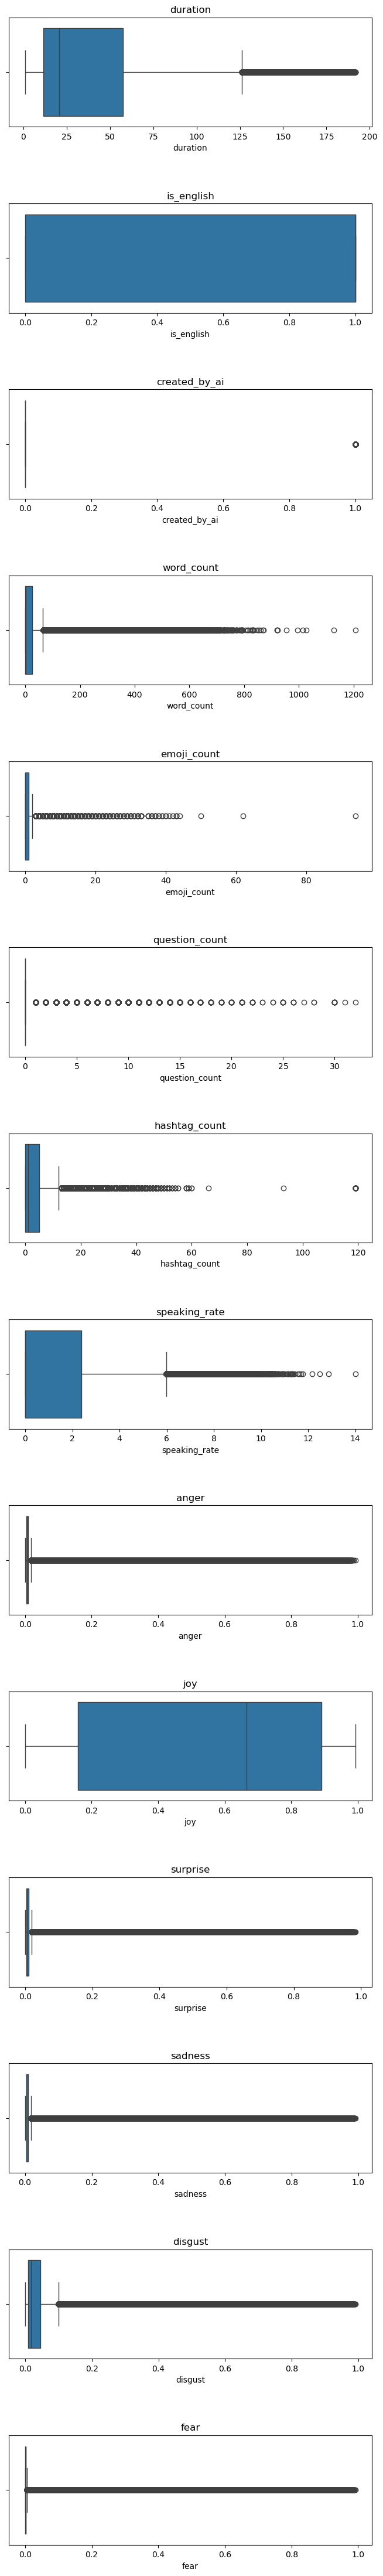

In [22]:
# Variables numéricas de videos

numericas_df = videos_df.select_dtypes(include=[np.number])

numericas_columnas = numericas_df.columns.values

fig, ax = plt.subplots(
    nrows=len(numericas_columnas),
    ncols=1,
    figsize=(8, 4 * len(numericas_columnas))
)

fig.subplots_adjust(hspace=0.7)

for i, col in enumerate(numericas_columnas):
    
    sns.boxplot(
        x=videos_df[col],
        ax=ax[i]
    )
    
    ax[i].set_title(col)

plt.show()

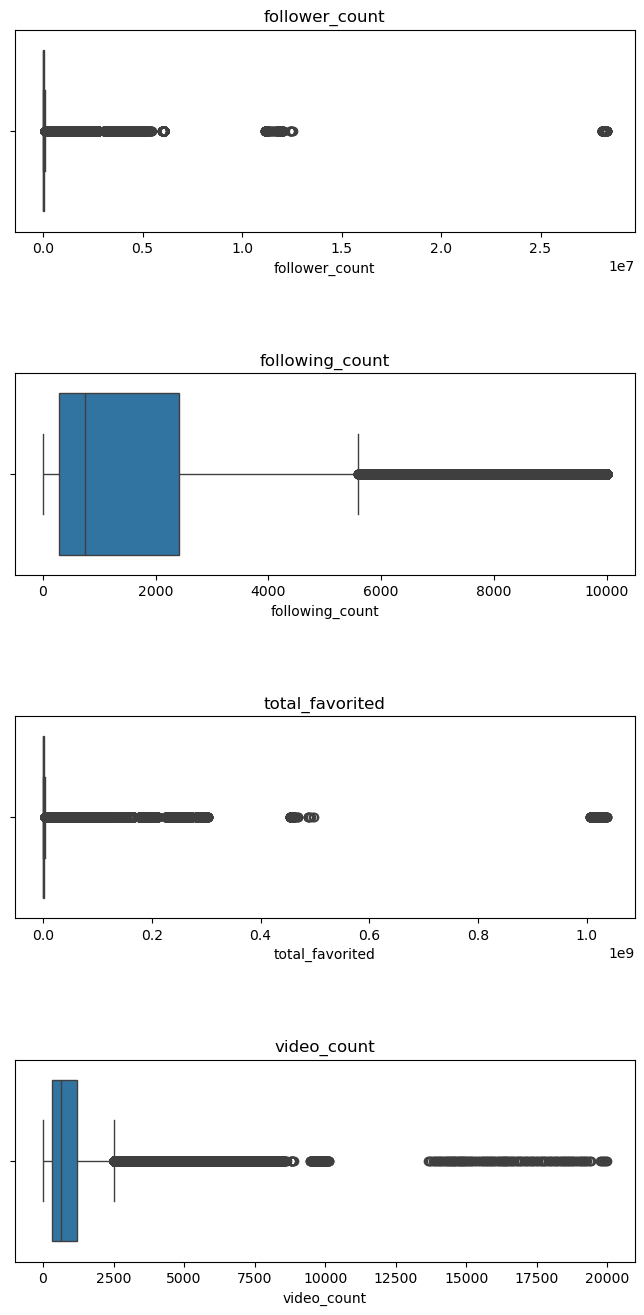

In [23]:
# Variables numéricas de creator

numericas_df = creator_df.select_dtypes(include=[np.number])

numericas_columnas = numericas_df.columns.values

fig, ax = plt.subplots(
    nrows=len(numericas_columnas),
    ncols=1,
    figsize=(8, 4 * len(numericas_columnas))
)

fig.subplots_adjust(hspace=0.7)

for i, col in enumerate(numericas_columnas):
    
    sns.boxplot(
        x=creator_df[col],
        ax=ax[i]
    )
    
    ax[i].set_title(col)

plt.show()

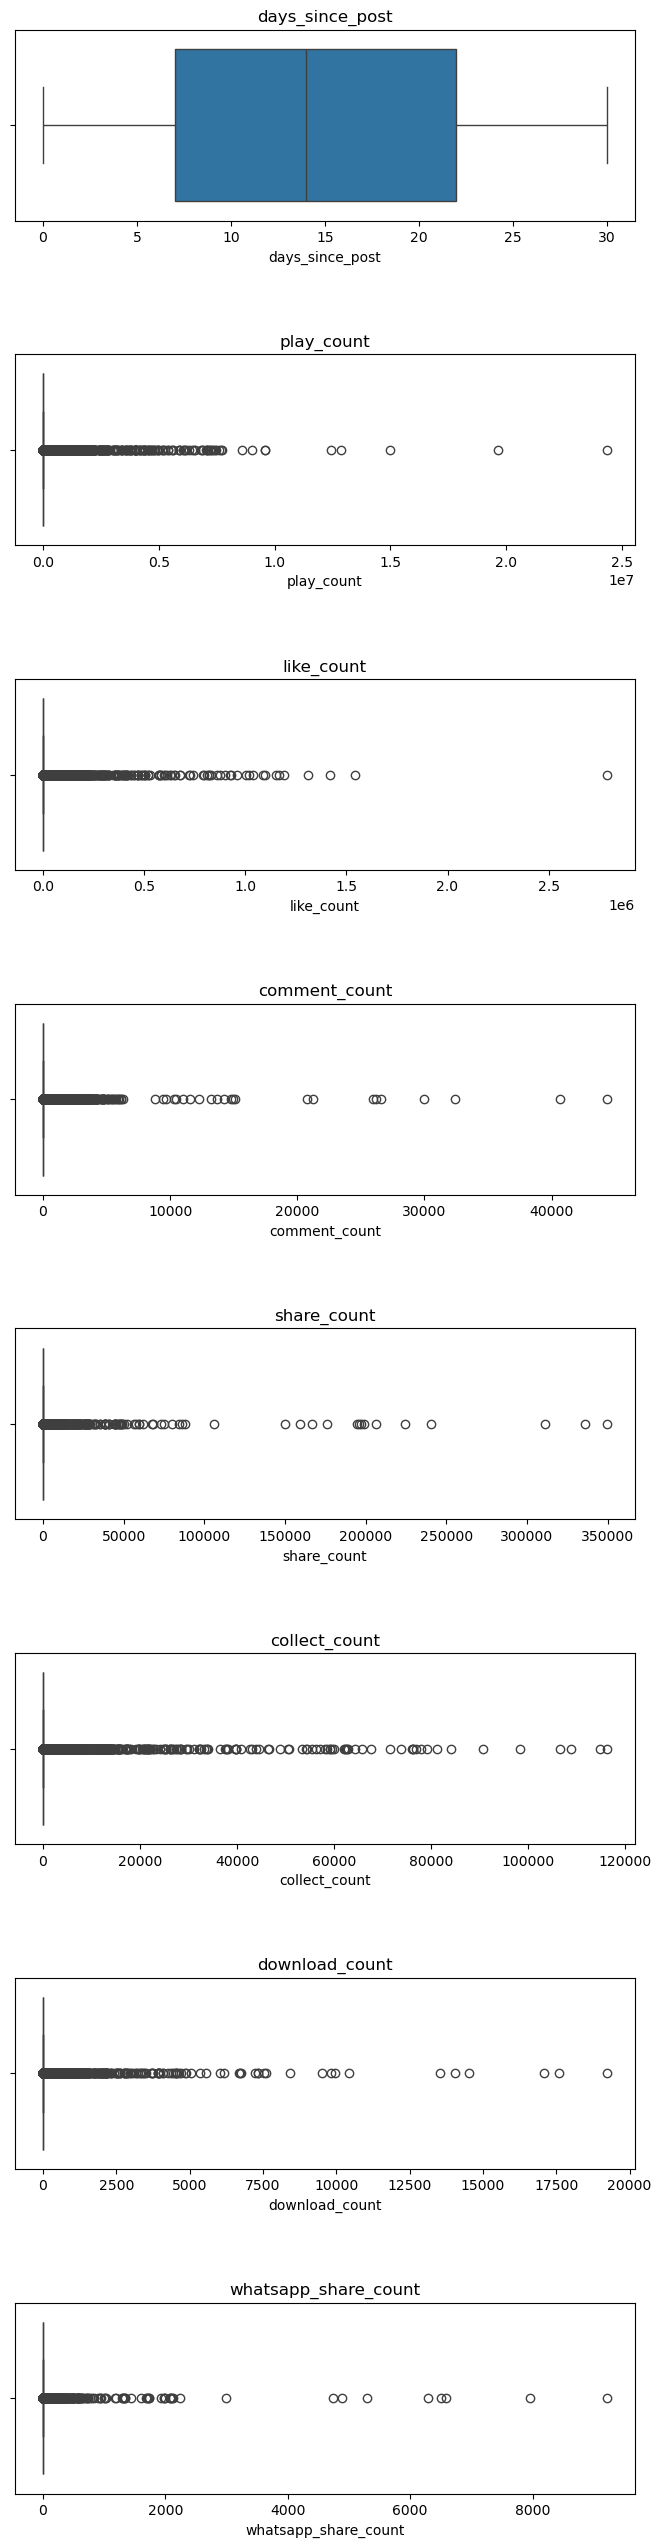

In [24]:
# Tiene más de seis millones de filas, usa una muestra para que el gráfico no tarde demasiado:
# Muestra aleatoria de 100.000 registros para visualizar engagement

engagement_muestra = engagement_df.sample(
    n=100_000,
    random_state=42
)

numericas_df = engagement_muestra.select_dtypes(include=[np.number])

numericas_columnas = numericas_df.columns.values

fig, ax = plt.subplots(
    nrows=len(numericas_columnas),
    ncols=1,
    figsize=(8, 4 * len(numericas_columnas))
)

fig.subplots_adjust(hspace=0.7)

for i, col in enumerate(numericas_columnas):
    
    sns.boxplot(
        x=engagement_muestra[col],
        ax=ax[i]
    )
    
    ax[i].set_title(col)

plt.show()

Tras la revisión gráfica, no se eliminan valores atípicos, ya que no se han identificado valores imposibles o errores de registro. Los valores extremos forman parte de la variabilidad natural de TikTok y son especialmente relevantes para el análisis de viralidad.

In [25]:
## Las emociones deben de estar entre 0 y 1
columnas_emociones = [
    "anger",
    "joy",
    "surprise",
    "sadness",
    "disgust",
    "fear"
]

valores_emociones_invalidos = (
    (videos_df[columnas_emociones] < 0) |
    (videos_df[columnas_emociones] > 1)
).sum()

display(valores_emociones_invalidos)

anger       0
joy         0
surprise    0
sadness     0
disgust     0
fear        0
dtype: int64

In [26]:
# Las variables de recuento no pueden ser negativas.

print("Valores negativos en engagement:")
display((engagement_df[columnas_engagement_outliers] < 0).sum())

print("Valores negativos en creator:")
display((creator_df[columnas_creator_outliers] < 0).sum())

print("Valores negativos en videos:")
display((videos_df[columnas_videos_outliers] < 0).sum())

Valores negativos en engagement:


days_since_post         0
play_count              0
like_count              0
comment_count           0
share_count             0
collect_count           0
download_count          0
whatsapp_share_count    0
dtype: int64

Valores negativos en creator:


follower_count     0
following_count    0
total_favorited    0
video_count        0
dtype: int64

Valores negativos en videos:


duration          0
speaking_rate     0
word_count        0
emoji_count       0
question_count    0
hashtag_count     0
dtype: int64

#### **3.5. Agrupación de Categorías**
---

In [27]:
# Se agrupan las resoluciones con presencia residual:
# 360p, 480p y 1080p pasan a la categoría "Otros".
# 540p y 720p se mantienen por tener mayor representación.

videos_df["ratio_agrupado"] = videos_df["ratio"]

videos_df.loc[
    ~videos_df["ratio"].isin(["540p", "720p", "Desconocido"]),
    "ratio_agrupado"
] = "Otros"

In [28]:
# Comprobación de la nueva distribución

videos_df["ratio_agrupado"].value_counts(dropna=False)

videos_df["ratio_agrupado"].value_counts(
    normalize=True,
    dropna=False
) * 100

ratio_agrupado
540p     92.713063
720p      6.826169
Otros     0.460768
Name: proportion, dtype: float64

In [29]:
#Una vez comprobado que está correcto, elimina la columna original:
videos_df = videos_df.drop(columns="ratio")

---
## **4. Definición de la Variable Objetivo**

La viralidad se define a partir del número de visualizaciones acumuladas a los 30 días desde la publicación del vídeo. Se considera viral aquel contenido cuyo valor de `play_count` se sitúa en el percentil 90 o superior de la distribución. Esta definición permite comparar todos los vídeos en el mismo horizonte temporal y obtener una variable objetivo binaria para un problema de clasificación.

In [30]:
# Primero comprobamos que existen observaciones a los 30 días
engagement_df["days_since_post"].value_counts().sort_index()

days_since_post
0     157065
1     206222
2     206193
3     206041
4     206012
5     206023
6     206052
7     206216
8     206227
9     206327
10    206030
11    205982
12    205937
13    206242
14    209543
15    205054
16    203386
17    201716
18    199919
19    198493
20    196937
21    195654
22    194117
23    193704
24    193197
25    193274
26    193021
27    193301
28    193465
29    193665
30     73940
Name: count, dtype: int64

In [31]:
# Se selecciona la métrica de cada vídeo cuando han pasado 30 días.

engagement_30_dias = engagement_df[
    engagement_df["days_since_post"] == 30
].copy()

print("Número de registros a los 30 días:", len(engagement_30_dias))

print(
    "Vídeos duplicados a los 30 días:",
    engagement_30_dias["video_id"].duplicated().sum()
)

Número de registros a los 30 días: 73940
Vídeos duplicados a los 30 días: 0


In [32]:
# Se calcula el percentil 90 de reproducciones.

umbral_viralidad = engagement_30_dias["play_count"].quantile(0.90)

print(f"Umbral de viralidad: {umbral_viralidad:,.0f} reproducciones")

Umbral de viralidad: 21,598 reproducciones


In [33]:
# Se crea la variable objetivo:
# 1 = vídeo viral
# 0 = vídeo no viral

engagement_30_dias["viral"] = 0

engagement_30_dias.loc[
    engagement_30_dias["play_count"] >= umbral_viralidad,
    "viral"
] = 1

engagement_30_dias["viral"] = (
    engagement_30_dias["viral"]
    .astype("int64")
)

In [34]:
# Comprobación de la distribución de la variable objetivo.

engagement_30_dias["viral"].value_counts()

engagement_30_dias["viral"].value_counts(normalize=True) * 100

viral
0    90.0
1    10.0
Name: proportion, dtype: float64

La variable objetivo presenta una distribución del 90 % de vídeos no virales y del 10 % de vídeos virales. Este resultado es coherente con la definición adoptada, basada en el percentil 90 de `play_count` a los 30 días. Aunque existe desequilibrio entre las clases, la proporción de casos virales es suficiente para entrenar un modelo de clasificación. El posible desequilibrio se abordará posteriormente durante la fase de modelado, sin modificar la distribución original del dataset.

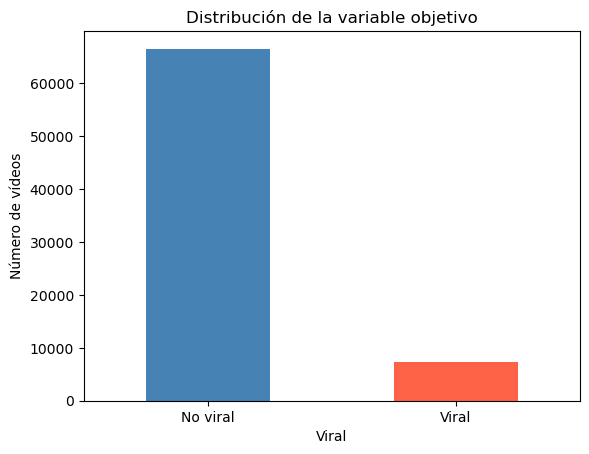

In [35]:
engagement_30_dias["viral"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Viral")
plt.ylabel("Número de vídeos")

plt.xticks([0, 1], ["No viral", "Viral"], rotation=0)

plt.show()

---
## **5. Unificación de los Datasets**

Una vez completado el proceso de limpieza y preprocesamiento de los tres datasets, se procede a integrar la información en un único conjunto de datos preparado para las siguientes fases del análisis y modelado.

La tabla principal será `videos_df`, ya que cada registro representa un vídeo único. Sobre esta tabla se incorporarán, por un lado, la variable objetivo de viralidad obtenida a partir de `engagement_df` y, por otro, las métricas correspondientes a cada creador procedentes de `creator_df`.

La unión con el dataset de engagement se realiza mediante la variable `video_id`. Únicamente se incorpora la etiqueta `viral`, calculada a partir de las visualizaciones acumuladas a los 30 días desde la publicación. Las demás métricas de engagement no se incluyen como variables predictoras, puesto que contienen información posterior a la publicación del vídeo y podrían provocar fuga de información.

La unión con `creator_df` se realiza mediante `author_id` y la fecha de referencia anterior a la publicación del vídeo. De este modo, se emplea exclusivamente información que estaría disponible antes de que el vídeo comenzara a recibir interacciones, evitando incorporar datos futuros del creador.

Como resultado, se obtiene `dataset_unificado`, donde cada fila representa un vídeo e incluye sus características, el estado previo del creador y la variable objetivo `viral`.

In [36]:
# Dataset que contiene únicamente la variable objetivo.
# No conservamos play_count porque se ha utilizado para crear viral.

objetivo_df = engagement_30_dias[
    ["video_id", "viral"]
].copy()

In [37]:
# Comprobación de que cada vídeo tiene una única etiqueta.

objetivo_df["video_id"].duplicated().sum()

np.int64(0)

In [38]:
# Se asegura que las claves tengan el mismo tipo de dato.

videos_df["video_id"] = videos_df["video_id"].astype("string")

objetivo_df["video_id"] = objetivo_df["video_id"].astype("string")

videos_df["author_id"] = videos_df["author_id"].astype("string")

creator_df["author_id"] = creator_df["author_id"].astype("string")

In [39]:
# Unión de videos con la variable objetivo.

filas_antes = len(videos_df)

dataset_unificado = videos_df.merge(
    objetivo_df,
    on="video_id",
    how="inner",
    validate="one_to_one"
)

print("Vídeos antes de unir la variable objetivo:", filas_antes)
print("Vídeos con variable objetivo:", len(dataset_unificado))
print("Vídeos descartados:", filas_antes - len(dataset_unificado))

Vídeos antes de unir la variable objetivo: 208565
Vídeos con variable objetivo: 73623
Vídeos descartados: 134942


In [40]:
# Se crea la fecha de referencia para unir los datos del creador.
# Se utiliza el día anterior a la publicación para evitar fuga de información.

dataset_unificado["fecha_referencia_creador"] = (
    dataset_unificado["create_time"].dt.normalize()
    - pd.Timedelta(days=1)
)

In [41]:
# Se cambia el nombre de date para poder unirlo con fecha_referencia_creador.

creator_para_unir = creator_df.rename(
    columns={"date": "fecha_referencia_creador"}
)

In [42]:
# Unión con las métricas diarias del creador.

dataset_unificado = dataset_unificado.merge(
    creator_para_unir,
    on=["author_id", "fecha_referencia_creador"],
    how="left",
    validate="many_to_one"
)

In [43]:
# Comprobación de la unión con creator_df.

porcentaje_creadores_unidos = (
    dataset_unificado["follower_count"].notna().mean() * 100
)

print(
    f"Porcentaje de vídeos con información del creador: "
    f"{porcentaje_creadores_unidos:.2f}%"
)

Porcentaje de vídeos con información del creador: 98.01%


In [44]:
# La fecha de referencia solo se ha usado para unir los datasets,
# por lo que puede eliminarse.

dataset_unificado = dataset_unificado.drop(
    columns="fecha_referencia_creador"
)

In [45]:
# Comprobación final del dataset unificado.

print("Dimensiones finales:", dataset_unificado.shape)

print("\nDistribución de la variable objetivo:")
display(dataset_unificado["viral"].value_counts())

display(dataset_unificado.head())

Dimensiones finales: (73623, 35)

Distribución de la variable objetivo:


viral
0    66234
1     7389
Name: count, dtype: int64

,video_id,author_id,create_time,duration,desc_language,is_english,desc,sticker_text,created_by_ai,music_selected_from,...,surprise,sadness,disgust,fear,ratio_agrupado,viral,follower_count,following_count,total_favorited,video_count
0,7386493327656504607,6958316329012003846,2024-06-30 21:46:54,20.067,un,0,#fallowme #foryoupage #fyp #fypp #goodengery #...,Sin información,0,edit_page_list,...,0.004642,0.011638,0.154876,0.001623,540p,0,2549.0,4782.0,3527.0,532.0
1,7384586135160261919,6825348786513626118,2024-06-25 18:25:55,10.449,en,1,Fable being the center of attention #catsoftik...,Sin información,0,shoot_page_search,...,0.003632,0.002551,0.010292,0.000383,540p,0,NaN,NaN,NaN,NaN
2,7386800802024754475,6822338188011865093,2024-07-01 17:39:53,45.467,en,1,This is IT 😂 I love y’all baaaad 🫶🏾❤️ Click th...,SHIRTS RESTOCKED‼️💕🚛,0,original,...,0.013656,0.004607,0.004065,0.000539,540p,0,20422.0,338.0,1034735.0,550.0
3,7386474017143754027,6792726896200139777,2024-06-30 20:31:47,66.467,en,1,Our Yard,Sin información,0,video_capsule_recommend,...,0.002883,0.007441,0.008705,0.000671,540p,0,3714.0,476.0,93735.0,2189.0
4,7386146638676397355,6792726896200139777,2024-06-29 23:21:40,14.793,un,0,#onthisday,Sin información,0,original,...,0.005094,0.007011,0.079359,0.000801,540p,0,3714.0,476.0,93730.0,2188.0


In [48]:
dataset_unificado.shape

(73623, 35)

In [46]:
dataset_unificado.columns.tolist()

['video_id',
 'author_id',
 'create_time',
 'duration',
 'desc_language',
 'is_english',
 'desc',
 'sticker_text',
 'created_by_ai',
 'music_selected_from',
 'music_album',
 'music_author',
 'music_owner_id',
 'music_id',
 'music_title',
 'transcript',
 'word_count',
 'emoji_count',
 'question_count',
 'hashtag_count',
 'speaking_rate',
 'gpt_summary',
 'topic',
 'anger',
 'joy',
 'surprise',
 'sadness',
 'disgust',
 'fear',
 'ratio_agrupado',
 'viral',
 'follower_count',
 'following_count',
 'total_favorited',
 'video_count']

---
## **6. Análisis Exploratorio del Dataset Unificado (EDA)**

Tras integrar las características de los vídeos, la información histórica de los creadores y la variable objetivo `viral`, se realiza un análisis exploratorio del dataset unificado.

El objetivo de esta fase es conocer la estructura final de los datos, comprobar la presencia de valores nulos y analizar la relación entre las características disponibles antes de la publicación y la viralidad del contenido.

En particular, se estudiará la distribución de las variables numéricas y categóricas, así como el porcentaje de vídeos virales según el tema, la resolución, el idioma, el uso de inteligencia artificial y las métricas previas de los creadores.

#### **6.1. Estructura General del Dataset**
---

In [49]:
# Dimensiones y tipos de datos

print("Dimensiones del dataset unificado:", dataset_unificado.shape)

dataset_unificado.info()

Dimensiones del dataset unificado: (73623, 35)
<class 'pandas.DataFrame'>
RangeIndex: 73623 entries, 0 to 73622
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   video_id             73623 non-null  string        
 1   author_id            73623 non-null  string        
 2   create_time          73623 non-null  datetime64[us]
 3   duration             73623 non-null  float64       
 4   desc_language        73623 non-null  str           
 5   is_english           73623 non-null  int64         
 6   desc                 73623 non-null  str           
 7   sticker_text         73623 non-null  str           
 8   created_by_ai        73623 non-null  int64         
 9   music_selected_from  73623 non-null  str           
 10  music_album          73623 non-null  str           
 11  music_author         73623 non-null  str           
 12  music_owner_id       73623 non-null  str           


In [50]:
# Valores nulos por variable

nulos_dataset = dataset_unificado.isnull().sum()

nulos_dataset = nulos_dataset[nulos_dataset > 0].sort_values(
    ascending=False
)

display(nulos_dataset)

follower_count     1468
following_count    1468
total_favorited    1468
video_count        1468
dtype: int64

In [51]:
# Duplicados según video_id

dataset_unificado["video_id"].duplicated().sum()

np.int64(0)

Tras la unificación, el dataset contiene 73.623 vídeos y 35 variables. No se observan registros duplicados según `video_id`. Sin embargo, las variables procedentes de `creator_df` presentan 1.468 valores nulos, equivalentes aproximadamente al 1,99 % de los registros. Estas ausencias se deben a la falta de una medición disponible del creador en la fecha de referencia previa a la publicación.

#### **6.2. Distribución de la Variable Objetivo**
---
La variable `viral` diferencia entre vídeos no virales (`0`) y vídeos virales (`1`). Se analizará su distribución para comprobar el equilibrio entre ambas clases.

In [52]:
# Recuento y porcentaje de vídeos virales y no virales

print(dataset_unificado["viral"].value_counts())

print(dataset_unificado["viral"].value_counts(normalize=True) * 100)

viral
0    66234
1     7389
Name: count, dtype: int64
viral
0    89.963734
1    10.036266
Name: proportion, dtype: float64


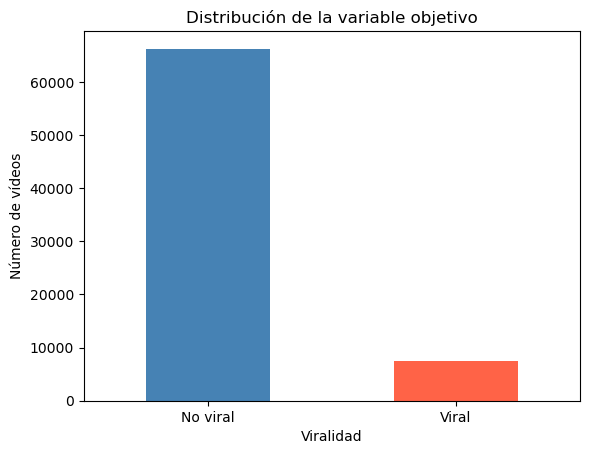

In [53]:
# Gráfico de la variable objetivo

dataset_unificado["viral"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Viralidad")
plt.ylabel("Número de vídeos")

plt.xticks([0, 1], ["No viral", "Viral"], rotation=0)

plt.show()

#### **6.3. Variables Categóricas y Viralidad**
---

A continuación, se analiza el porcentaje de vídeos virales en función de las principales variables categóricas disponibles.

In [54]:
# Porcentaje de viralidad por tema

viralidad_topic = (
    dataset_unificado
    .groupby("topic")["viral"]
    .agg(["count", "mean"])
    .reset_index()
)

viralidad_topic["porcentaje_viral"] = (
    viralidad_topic["mean"] * 100
)

viralidad_topic = viralidad_topic.sort_values(
    "porcentaje_viral",
    ascending=False
)

display(viralidad_topic)

,topic,count,mean,porcentaje_viral
8,Sports_Fitness,4003,0.181864,18.186360
1,Cooking_Food,4370,0.167735,16.773455
5,Movies_TV_Books,3802,0.138611,13.861126
6,Others,12616,0.110495,11.049461
7,Shopping_Products,3450,0.097971,9.797101
2,Dance_Music,9588,0.091677,9.167710
3,Life_hacks_Personal_growth,11228,0.090043,9.004275
4,Lifestyle,8834,0.079126,7.912610
0,Beauty_Fashion,15732,0.068650,6.864989


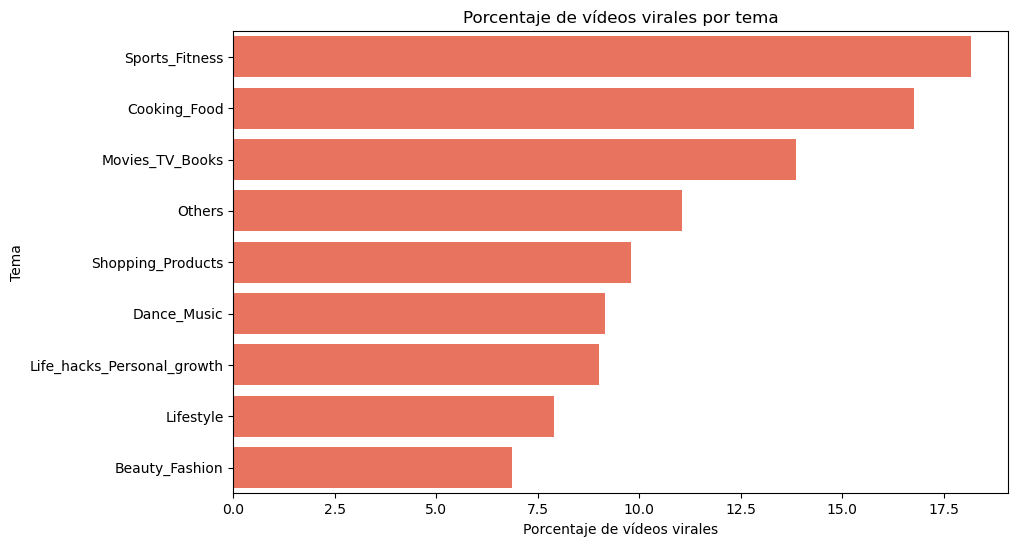

In [55]:
# Gráfico: porcentaje de viralidad por tema

plt.figure(figsize=(10, 6))

sns.barplot(
    data=viralidad_topic,
    y="topic",
    x="porcentaje_viral",
    color="tomato"
)

plt.title("Porcentaje de vídeos virales por tema")
plt.xlabel("Porcentaje de vídeos virales")
plt.ylabel("Tema")

plt.show()

In [56]:
# Porcentaje de viralidad por resolución agrupada

viralidad_resolucion = (
    dataset_unificado
    .groupby("ratio_agrupado")["viral"]
    .agg(["count", "mean"])
    .reset_index()
)

viralidad_resolucion["porcentaje_viral"] = (
    viralidad_resolucion["mean"] * 100
)

viralidad_resolucion = viralidad_resolucion.sort_values(
    "porcentaje_viral",
    ascending=False
)

display(viralidad_resolucion)

,ratio_agrupado,count,mean,porcentaje_viral
0,540p,68346,0.103400,10.340035
1,720p,4962,0.061064,6.106409
2,Otros,315,0.060317,6.031746


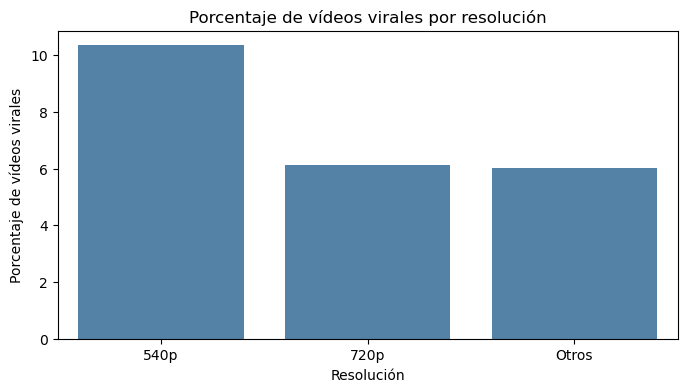

In [57]:
# Gráfico: porcentaje de viralidad por resolución

plt.figure(figsize=(8, 4))

sns.barplot(
    data=viralidad_resolucion,
    x="ratio_agrupado",
    y="porcentaje_viral",
    color="steelblue"
)

plt.title("Porcentaje de vídeos virales por resolución")
plt.xlabel("Resolución")
plt.ylabel("Porcentaje de vídeos virales")

plt.show()

In [58]:
# Porcentaje de viralidad según el idioma de la descripción

viralidad_idioma = (
    dataset_unificado
    .groupby("is_english")["viral"]
    .agg(["count", "mean"])
    .reset_index()
)

viralidad_idioma["porcentaje_viral"] = (
    viralidad_idioma["mean"] * 100
)

display(viralidad_idioma)

,is_english,count,mean,porcentaje_viral
0,0,26431,0.041656,4.165563
1,1,47192,0.133243,13.324292


In [59]:
# Porcentaje de viralidad según si el contenido ha sido creado por IA

viralidad_ia = (
    dataset_unificado
    .groupby("created_by_ai")["viral"]
    .agg(["count", "mean"])
    .reset_index()
)

viralidad_ia["porcentaje_viral"] = (
    viralidad_ia["mean"] * 100
)

display(viralidad_ia)

,created_by_ai,count,mean,porcentaje_viral
0,0,73324,0.100499,10.049915
1,1,299,0.066890,6.688963


Los resultados muestran diferencias relevantes en la proporción de vídeos virales según la temática. Los contenidos de deporte y fitness, cocina y películas, televisión o libros presentan los porcentajes de viralidad más elevados.

Asimismo, los vídeos con descripción en inglés presentan una mayor proporción de viralidad que aquellos cuya descripción no está en inglés. En cambio, los resultados asociados a `created_by_ai` deben interpretarse con cautela, ya que la categoría de vídeos creados mediante inteligencia artificial contiene un número muy reducido de observaciones.

#### **6.4. Variables Numéricas y Viralidad**
---
Se compara la mediana de las principales variables numéricas entre vídeos virales y no virales. Se utiliza la mediana debido a la presencia de distribuciones asimétricas y valores extremos.

In [60]:
# Mediana de las variables numéricas según la viralidad

variables_numericas = [
    "duration",
    "word_count",
    "emoji_count",
    "question_count",
    "hashtag_count",
    "speaking_rate",
    "follower_count",
    "following_count",
    "total_favorited",
    "video_count"
]

medianas_viralidad = (
    dataset_unificado
    .groupby("viral")[variables_numericas]
    .median()
    .T
)

display(medianas_viralidad)

viral,0,1
duration,19.1,4.186700e+01
word_count,3.0,1.400000e+01
emoji_count,0.0,0.000000e+00
question_count,0.0,0.000000e+00
hashtag_count,1.0,1.000000e+00
speaking_rate,0.0,0.000000e+00
follower_count,11311.0,2.345660e+05
following_count,1053.0,3.520000e+02
total_favorited,261227.0,1.019110e+07
video_count,1113.0,1.208500e+03


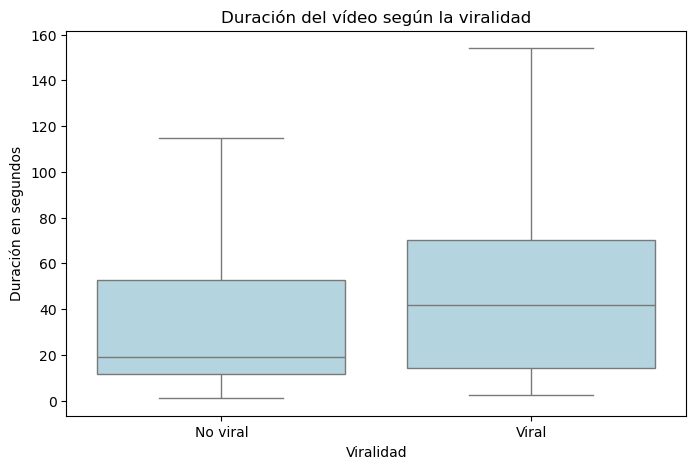

In [61]:
# Duración de los vídeos según la viralidad.
# showfliers=False solo oculta los puntos extremos del gráfico;
# no elimina ningún registro del dataset.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=dataset_unificado,
    x="viral",
    y="duration",
    showfliers=False,
    color="lightblue"
)

plt.title("Duración del vídeo según la viralidad")
plt.xlabel("Viralidad")
plt.ylabel("Duración en segundos")

plt.xticks([0, 1], ["No viral", "Viral"])

plt.show()

In [62]:
# Se crea una copia solo para visualizar los seguidores en escala logarítmica.
# No se modifica el dataset original.

datos_seguidores = dataset_unificado[
    ["viral", "follower_count"]
].copy()

datos_seguidores["log_follower_count"] = np.log1p(
    datos_seguidores["follower_count"]
)

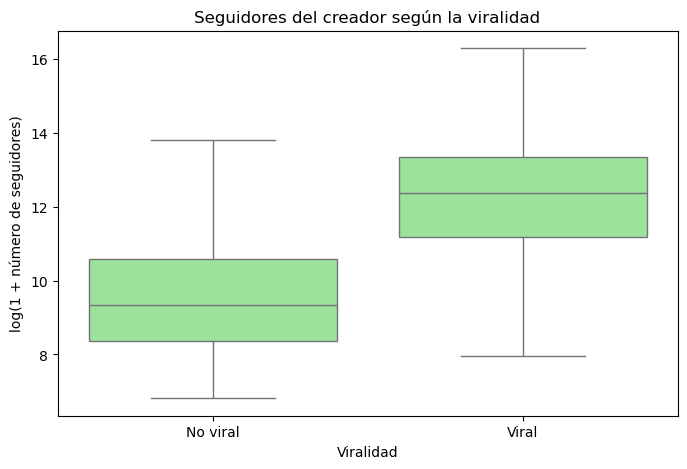

In [63]:
# Seguidores del creador según la viralidad

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=datos_seguidores,
    x="viral",
    y="log_follower_count",
    showfliers=False,
    color="lightgreen"
)

plt.title("Seguidores del creador según la viralidad")
plt.xlabel("Viralidad")
plt.ylabel("log(1 + número de seguidores)")

plt.xticks([0, 1], ["No viral", "Viral"])

plt.show()

#### **6.5. Correlación entre Variables Numéricas y Viralidad**
---
Finalmente, se calcula la correlación lineal entre las variables numéricas y la variable objetivo. Este análisis permite identificar variables que podrían tener una mayor relación inicial con la viralidad.

In [64]:
# Correlación de cada variable numérica con la variable objetivo

correlacion_viralidad = (
    dataset_unificado
    .select_dtypes(include=[np.number])
    .corr()["viral"]
    .drop("viral")
    .sort_values()
)

display(correlacion_viralidad)

following_count   -0.147935
disgust           -0.008221
created_by_ai     -0.007114
joy               -0.004623
video_count       -0.003558
sadness            0.005924
hashtag_count      0.006267
fear               0.006335
emoji_count        0.007438
anger              0.021954
surprise           0.029626
speaking_rate      0.086596
question_count     0.110419
duration           0.117319
is_english         0.146215
word_count         0.159797
follower_count     0.337953
total_favorited    0.356314
Name: viral, dtype: float64

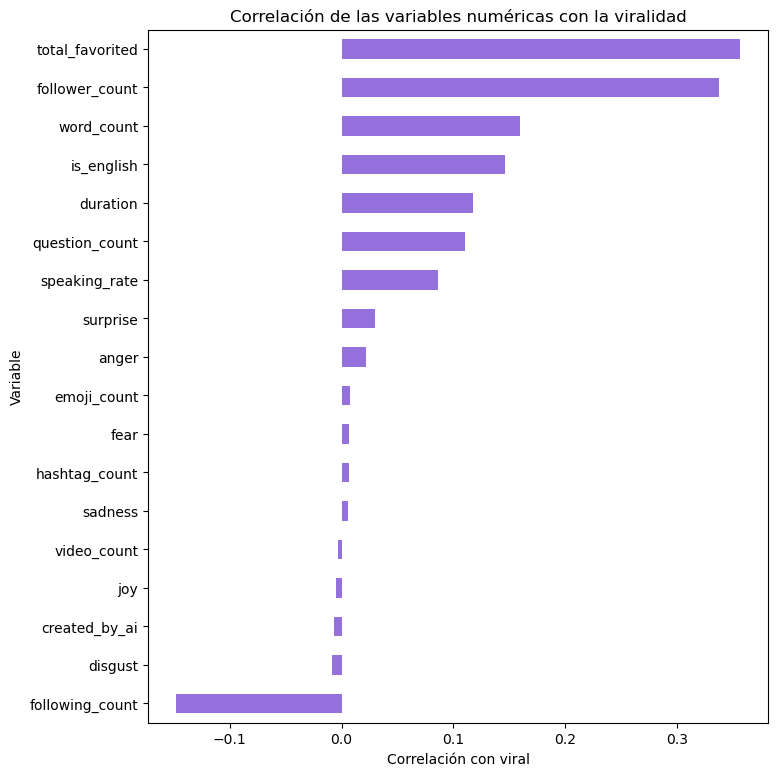

In [65]:
# Gráfico de correlaciones

plt.figure(figsize=(8, 9))

correlacion_viralidad.plot(
    kind="barh",
    color="mediumpurple"
)

plt.title("Correlación de las variables numéricas con la viralidad")
plt.xlabel("Correlación con viral")
plt.ylabel("Variable")

plt.show()

Los vídeos virales presentan una duración y un número de palabras en la descripción superiores a los vídeos no virales. Además, los creadores asociados a vídeos virales muestran, en términos generales, un mayor número de seguidores y un mayor historial de likes acumulados.

Las correlaciones más elevadas con la variable objetivo corresponden a `total_favorited` y `follower_count`. Esto sugiere que la audiencia previa y la popularidad histórica del creador pueden ser factores relevantes para predecir la viralidad. No obstante, la correlación no implica causalidad y estas relaciones se evaluarán posteriormente mediante modelos predictivos.

#### **6.6. Conclusiones del EDA**
---
El análisis exploratorio muestra que la viralidad no depende únicamente de las características propias del vídeo, sino también del perfil previo del creador. Las variables `follower_count` y `total_favorited` presentan la mayor asociación lineal con la variable objetivo, por lo que serán especialmente relevantes durante la fase de modelado.

Entre las características del contenido, la duración, el número de palabras de la descripción, el idioma y la temática muestran diferencias entre vídeos virales y no virales. Estos resultados justifican la creación de variables derivadas relacionadas con el contenido textual, el momento de publicación y las métricas históricas de los creadores.

Finalmente, se detecta una proporción reducida de registros sin información del creador. Este aspecto deberá resolverse antes de la fase de modelado para garantizar la consistencia del dataset final.

> Limitación: la variable objetivo se ha definido utilizando las visualizaciones acumuladas a los 30 días. Por ello, únicamente se incluyen los vídeos que disponen de una observación en dicho horizonte temporal, reduciendo el tamaño de la muestra final. Esta decisión se tendrá en cuenta al interpretar los resultados del modelo.

---
## **7. Ingeniería de Características (Feature Engineering)**

A partir de los resultados del análisis exploratorio, se crean nuevas variables que permiten representar de forma más útil la información disponible en el momento de publicación del vídeo.

Se incorporan características temporales de publicación, indicadores derivados del contenido, transformaciones logarítmicas de variables altamente asimétricas y métricas relativas del perfil del creador.

No se utilizan métricas de engagement posteriores a la publicación, como visualizaciones, likes, comentarios o compartidos, con el objetivo de evitar fuga de información.

#### **7.1. Tratamiento de Valores Nulos restantes**
---

Tras la unión de los datasets, algunos vídeos no disponen de información histórica del creador. Dado que estos registros representan aproximadamente el 2 % de la muestra, se eliminan para trabajar con un dataset completo.

In [67]:
# Se crea una copia del dataset unificado.

dataset_modelo = dataset_unificado.copy()

In [68]:
# Se eliminan los vídeos sin información del creador.

columnas_creator = [
    "follower_count",
    "following_count",
    "total_favorited",
    "video_count"
]

filas_antes = len(dataset_modelo)

dataset_modelo = dataset_modelo.dropna(subset=columnas_creator)

filas_eliminadas = filas_antes - len(dataset_modelo)

print(f"Filas eliminadas: {filas_eliminadas}")
print(f"Porcentaje eliminado: {filas_eliminadas / filas_antes * 100:.2f}%")

Filas eliminadas: 1468
Porcentaje eliminado: 1.99%


#### **7.2. Características Temporales de Publicación**
---

La hora y el día de publicación pueden influir en la visibilidad inicial del contenido. Por ello, se extraen variables temporales a partir de `create_time`.

In [70]:
# Hora de publicación: valores entre 0 y 23.

dataset_modelo["hora_publicacion"] = (
    dataset_modelo["create_time"].dt.hour
)

In [71]:
# Día de la semana:
# 0 = lunes, 1 = martes, ..., 6 = domingo.

dataset_modelo["dia_semana_publicacion"] = (
    dataset_modelo["create_time"].dt.dayofweek
)

In [72]:
# Indicador de fin de semana:
# 1 = sábado o domingo
# 0 = lunes a viernes

dataset_modelo["es_fin_semana"] = 0

dataset_modelo.loc[
    dataset_modelo["dia_semana_publicacion"] >= 5,
    "es_fin_semana"
] = 1

#### **7.3. Características Derivadas del Contenido**
---
Se crean indicadores que reflejan la presencia de texto, transcripción, texto añadido al vídeo, emojis y preguntas. También se crean variables relacionadas con la intensidad y el balance emocional.

In [73]:
# Indicadores de presencia de contenido textual.

dataset_modelo["tiene_descripcion"] = 0

dataset_modelo.loc[
    dataset_modelo["desc"] != "Sin información",
    "tiene_descripcion"
] = 1

In [74]:
dataset_modelo["tiene_transcripcion"] = 0

dataset_modelo.loc[
    dataset_modelo["transcript"] != "Sin información",
    "tiene_transcripcion"
] = 1

In [75]:
dataset_modelo["tiene_sticker_texto"] = 0

dataset_modelo.loc[
    dataset_modelo["sticker_text"] != "Sin información",
    "tiene_sticker_texto"
] = 1

In [76]:
# Indicadores de uso de emojis y preguntas.

dataset_modelo["tiene_emoji"] = 0

dataset_modelo.loc[
    dataset_modelo["emoji_count"] > 0,
    "tiene_emoji"
] = 1

In [77]:
dataset_modelo["tiene_pregunta"] = 0

dataset_modelo.loc[
    dataset_modelo["question_count"] > 0,
    "tiene_pregunta"
] = 1

In [78]:
# Intensidad emocional total.

dataset_modelo["intensidad_emocional"] = (
    dataset_modelo["anger"]
    + dataset_modelo["joy"]
    + dataset_modelo["surprise"]
    + dataset_modelo["sadness"]
    + dataset_modelo["disgust"]
    + dataset_modelo["fear"]
)

In [79]:
# Balance emocional:
# Valores positivos indican predominio de alegría.
# Valores negativos indican predominio de emociones negativas.

dataset_modelo["emocion_negativa"] = (
    dataset_modelo["anger"]
    + dataset_modelo["sadness"]
    + dataset_modelo["disgust"]
    + dataset_modelo["fear"]
)

dataset_modelo["balance_emocional"] = (
    dataset_modelo["joy"]
    - dataset_modelo["emocion_negativa"]
)

#### **7.4. Transformaciones Logarítmicas y Métricas del creador**
---

Las métricas relacionadas con los creadores presentan una fuerte asimetría positiva. Se aplican transformaciones logarítmicas para reducir el efecto de los valores extremos y facilitar su uso en futuros modelos.

También se crean métricas relativas para representar la popularidad del creador en relación con su actividad.

In [80]:
# Transformaciones logarítmicas.

dataset_modelo["log_follower_count"] = np.log1p(
    dataset_modelo["follower_count"]
)

dataset_modelo["log_following_count"] = np.log1p(
    dataset_modelo["following_count"]
)

dataset_modelo["log_total_favorited"] = np.log1p(
    dataset_modelo["total_favorited"]
)

dataset_modelo["log_video_count"] = np.log1p(
    dataset_modelo["video_count"]
)

dataset_modelo["log_duration"] = np.log1p(
    dataset_modelo["duration"]
)

dataset_modelo["log_word_count"] = np.log1p(
    dataset_modelo["word_count"]
)

In [81]:
# Métricas relativas del creador.

dataset_modelo["seguidores_por_video"] = (
    dataset_modelo["follower_count"]
    / dataset_modelo["video_count"]
)

dataset_modelo["likes_historicos_por_video"] = (
    dataset_modelo["total_favorited"]
    / dataset_modelo["video_count"]
)

#### **7.5. Eliminación de Variables No Utilizables Directamente**
---
Se eliminan identificadores, marcas temporales originales y textos en bruto. Estas variables no pueden utilizarse directamente en la mayoría de modelos de machine learning o presentan una cardinalidad demasiado elevada.

Se mantienen las variables derivadas creadas anteriormente, así como las características categóricas que podrán codificarse durante la fase de modelado.

In [82]:
columnas_a_eliminar = [
    "video_id",
    "author_id",
    "create_time",
    "desc",
    "sticker_text",
    "transcript",
    "gpt_summary",
    "music_album",
    "music_author",
    "music_owner_id",
    "music_id",
    "music_title"
]

dataset_modelo = dataset_modelo.drop(
    columns=columnas_a_eliminar
)

#### **7.6. Comprobaciones Finales de las Nuevas Características**
---

In [84]:
print("Dimensiones del dataset preparado:", dataset_modelo.shape)

print("\nValores nulos:")
display(
    dataset_modelo.isnull().sum().sort_values(ascending=False)
)

Dimensiones del dataset preparado: (72155, 42)

Valores nulos:


duration                      0
intensidad_emocional          0
hora_publicacion              0
dia_semana_publicacion        0
es_fin_semana                 0
tiene_descripcion             0
tiene_transcripcion           0
tiene_sticker_texto           0
tiene_emoji                   0
tiene_pregunta                0
emocion_negativa              0
desc_language                 0
balance_emocional             0
log_follower_count            0
log_following_count           0
log_total_favorited           0
log_video_count               0
log_duration                  0
log_word_count                0
seguidores_por_video          0
video_count                   0
total_favorited               0
following_count               0
follower_count                0
is_english                    0
created_by_ai                 0
music_selected_from           0
word_count                    0
emoji_count                   0
question_count                0
hashtag_count                 0
speaking

In [85]:
# Vista previa del dataset preparado.

display(dataset_modelo.head())

,duration,desc_language,is_english,created_by_ai,music_selected_from,word_count,emoji_count,question_count,hashtag_count,speaking_rate,...,emocion_negativa,balance_emocional,log_follower_count,log_following_count,log_total_favorited,log_video_count,log_duration,log_word_count,seguidores_por_video,likes_historicos_por_video
0,20.067,un,0,0,edit_page_list,0,0,0,14,0.000000,...,0.175424,0.252141,7.843849,8.472823,8.168486,6.278521,3.047708,0.000000,4.791353,6.629699
2,45.467,en,1,0,original,218,6,4,6,9.039523,...,0.014346,0.820242,9.924417,5.826000,13.849657,6.311735,3.838742,5.389072,37.130909,1881.336364
3,66.467,en,1,0,video_capsule_recommend,2,0,0,0,0.000000,...,0.019240,0.895001,8.220134,6.167516,11.448238,7.691657,4.211639,1.098612,1.696665,42.820923
4,14.793,un,0,0,original,0,0,0,1,0.000000,...,0.093188,0.705462,8.220134,6.167516,11.448184,7.691200,2.759567,0.000000,1.697441,42.838208
5,14.001,en,1,0,single_song,11,2,0,9,0.000000,...,0.006311,0.953321,9.452580,6.440947,14.176216,5.683580,2.708117,2.484907,43.481229,4895.358362


Como resultado, se obtiene `dataset_modelo`, un conjunto de datos preparado para la etapa de modelado. La codificación de las variables categóricas y la normalización, si fueran necesarias, se realizarán después de separar los datos en entrenamiento y prueba para evitar fuga de información.

## **8. Comprobaciones Finales del Dataset**

Antes de exportar el dataset preparado, se realizan comprobaciones finales para verificar que los datos están completos, no contienen valores inválidos, no incluyen variables con fuga de información y mantienen correctamente la variable objetivo.

El dataset resultante será utilizado posteriormente en la fase de división temporal, codificación de variables categóricas y entrenamiento de modelos.

#### **8.1. Dimensiones y Estructura Final**
---

In [86]:
print("Dimensiones finales:", dataset_modelo.shape)

dataset_modelo.info()

Dimensiones finales: (72155, 42)
<class 'pandas.DataFrame'>
Index: 72155 entries, 0 to 73622
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   duration                    72155 non-null  float64
 1   desc_language               72155 non-null  str    
 2   is_english                  72155 non-null  int64  
 3   created_by_ai               72155 non-null  int64  
 4   music_selected_from         72155 non-null  str    
 5   word_count                  72155 non-null  int64  
 6   emoji_count                 72155 non-null  int64  
 7   question_count              72155 non-null  int64  
 8   hashtag_count               72155 non-null  int64  
 9   speaking_rate               72155 non-null  float64
 10  topic                       72155 non-null  str    
 11  anger                       72155 non-null  float64
 12  joy                         72155 non-null  float64
 13  surprise      

#### **8.2. Valores Nulos y Valores Infinitos**
---

In [87]:
# Comprobación de valores nulos.

nulos_finales = dataset_modelo.isnull().sum()

nulos_finales = nulos_finales[nulos_finales > 0]

print("Valores nulos restantes:")
display(nulos_finales)

Valores nulos restantes:


Series([], dtype: int64)

In [88]:
# Comprobación de valores infinitos en variables numéricas.

variables_numericas_finales = dataset_modelo.select_dtypes(
    include=[np.number]
)

valores_infinitos = np.isinf(
    variables_numericas_finales
).sum()

valores_infinitos = valores_infinitos[
    valores_infinitos > 0
]

print("Valores infinitos restantes:")
display(valores_infinitos)

Valores infinitos restantes:


seguidores_por_video          28
likes_historicos_por_video    28
dtype: int64

#### **8.3. Duplicados e Identificadores**
---

In [90]:
# Los duplicados por video_id se comprobaron antes de eliminar
# el identificador durante la ingeniería de características.

print(
    "Duplicados por video_id en dataset_unificado:",
    dataset_unificado["video_id"].duplicated().sum()
)

Duplicados por video_id en dataset_unificado: 0


In [91]:
# Comprobación de filas completamente idénticas
# en el dataset preparado.

print(
    "Filas completamente duplicadas:",
    dataset_modelo.duplicated().sum()
)

Filas completamente duplicadas: 0


#### **8.4. Variables Constantes y Fuga de Información**
---

In [92]:
# Una variable constante no aporta capacidad predictiva.

variables_constantes = []

for columna in dataset_modelo.columns:
    
    if dataset_modelo[columna].nunique() <= 1:
        variables_constantes.append(columna)

print("Variables constantes:", variables_constantes)

Variables constantes: []


In [93]:
# Si existiera alguna variable constante, se elimina.

dataset_modelo = dataset_modelo.drop(
    columns=variables_constantes,
    errors="ignore"
)

In [94]:
# Comprobación de que no se han conservado métricas
# de engagement posteriores a la publicación.

variables_leakage = [
    "play_count",
    "like_count",
    "comment_count",
    "share_count",
    "collect_count",
    "download_count",
    "whatsapp_share_count",
    "days_since_post"
]

columnas_con_leakage = []

for columna in variables_leakage:
    
    if columna in dataset_modelo.columns:
        columnas_con_leakage.append(columna)

print("Variables con posible fuga de información:")
print(columnas_con_leakage)

Variables con posible fuga de información:
[]


#### **8.5. Variable Objetivo y Tipos de Datos**
---

In [95]:
# Comprobación de que la variable objetivo sigue presente.

print("¿Existe la variable viral?:", "viral" in dataset_modelo.columns)

print("\nDistribución de viral:")
display(dataset_modelo["viral"].value_counts())

print("\nPorcentaje de viralidad:")
display(dataset_modelo["viral"].value_counts(normalize=True) * 100)

¿Existe la variable viral?: True

Distribución de viral:


viral
0    64907
1     7248
Name: count, dtype: int64


Porcentaje de viralidad:


viral
0    89.954958
1    10.045042
Name: proportion, dtype: float64

In [96]:
# Tipos de variables presentes.

print("Tipos de datos:")
display(dataset_modelo.dtypes.value_counts())

print("Variables categóricas:")
display(
    dataset_modelo.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()
)

Tipos de datos:


float64    23
int64      13
str         4
int32       2
Name: count, dtype: int64

Variables categóricas:


['desc_language', 'music_selected_from', 'topic', 'ratio_agrupado']

#### Conclusión de las comprobaciones finales

Tras las verificaciones realizadas, el dataset no debe contener valores nulos, infinitos, duplicados por identificador, variables constantes ni métricas de engagement posteriores a la publicación. La variable objetivo `viral` se mantiene correctamente y el dataset queda preparado para su exportación.

## **9. Exportación del Dataset Preparado**

El dataset final se exporta en formato Parquet. Este formato conserva los tipos de datos, ocupa menos espacio que CSV y permite una carga más eficiente en las siguientes fases del proyecto.

In [97]:
# Ruta de exportación

ruta_exportacion = "../datos/dataset_modelo.parquet"

In [98]:
# Exportación del dataset final.

dataset_modelo.to_parquet(
    ruta_exportacion,
    index=False
)

print(f"Dataset exportado correctamente en: {ruta_exportacion}")

Dataset exportado correctamente en: ../datos/dataset_modelo.parquet


In [99]:
# Comprobación de la exportación.

dataset_exportado = pd.read_parquet(ruta_exportacion)

print("Dimensiones del dataset exportado:")
print(dataset_exportado.shape)

print("\n¿Las dimensiones coinciden?")
print(dataset_exportado.shape == dataset_modelo.shape)

print("\n¿Las columnas coinciden?")
print(
    dataset_exportado.columns.tolist()
    == dataset_modelo.columns.tolist()
)

Dimensiones del dataset exportado:
(72155, 42)

¿Las dimensiones coinciden?
True

¿Las columnas coinciden?
True
